# Initialization of libraries to be used as well as loading of the data. <br>
> additionally remove rows that are not relevant.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sb
plt.style.use('seaborn-v0_8-whitegrid')
sb.set_palette("husl")

In [22]:
df = pd.read_csv("data/beatmaps.csv")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
print(df.columns.to_list())
df = df.drop(columns=['file_md5', 'tags', 'download_unavailable', 'audio_unavailable'])

['beatmapset_id', 'beatmap_id', 'approved', 'total_length', 'hit_length', 'version', 'file_md5', 'diff_size', 'diff_overall', 'diff_approach', 'diff_drain', 'mode', 'count_normal', 'count_slider', 'count_spinner', 'submit_date', 'approved_date', 'last_update', 'artist', 'title', 'creator', 'creator_id', 'bpm', 'source', 'tags', 'genre_id', 'language_id', 'favourite_count', 'rating', 'download_unavailable', 'audio_unavailable', 'playcount', 'passcount', 'max_combo', 'diff_aim', 'diff_speed', 'difficultyrating']


# Adjust the data by removing rows that are not relevant to this project. <br>
> Remove all rows where mode is not 0 (the standard osu game mode). <br>
> Remove all rows that are either pending (0), WIP (-1), or graveyard (-2) <br>
> Remove all rows where the total song time is less than 40 seconds or greater than 2 standard deviations from the mean. <br>
> Remove all rows where the Drain Ratio (Hit length / Total Length) is less than 0.6, This means that the map is less than 60% game time and a large part is empty audio (intros, outros, massive breaks) and is a good indicator of > a low-quality beatmap. <br>
>Remove maps where there are impossible statisitcs / data collection inaccurary (bpm >= 500, difficultyrating >= 11) <br>
Any map that falls into one of these categories will be considered as these maps are generally incomplete or of low quality (meme maps, endurance maps, practice maps, etc).

In [23]:
# Drop the rows using their indices, modifying the DataFrame in-place
df.drop(df[df['mode'] != 0].index, inplace= True)
df.drop(df[df['approved'].isin([0, -1, -2])].index, inplace=True)
#calculate bounds
total_length_mean_val = df['total_length'].mean()
total_length_std_val = df['total_length'].std()
hit_length_mean_val = df['hit_length'].mean()
hit_length_std_val = df['hit_length'].std()
min_total_length = 40
max_total_length = total_length_mean_val + 2 * total_length_std_val
max_hit_length = hit_length_mean_val + 2 * hit_length_std_val
# Overwrite df with only the rows that meet the length criteria
df = df[
    (df['total_length'] >= min_total_length) & 
    (df['total_length'] <= max_total_length) &
    (df['hit_length'] >= min_total_length) &
    (df['hit_length'] <= max_hit_length)
]

# Calculate drain ratio, keep the high-quality maps, and drop the temporary column
df['drain_ratio'] = df['hit_length'] / df['total_length']
df = df[df['drain_ratio'] >= 0.60]
df = df.drop(columns=['drain_ratio'])

#Remove impossible beatmaps
df.drop(df[(df['bpm'] >= 500) | (df['bpm'] == 0)].index, inplace=True)
df.drop(df[df['difficultyrating'] >= 11].index, inplace= True)

# Summary statistics for the key numerical variables involved in our analysis.

In [24]:
df[['total_length', 'bpm', 'difficultyrating', 'count_normal', 'count_slider', 'count_spinner', 'playcount', 'favourite_count']].describe().round(2)

,total_length,bpm,difficultyrating,count_normal,count_slider,count_spinner,playcount,favourite_count
count,61686.00,61686.00,61686.00,61686.00,61686.00,61686.00,61686.00,61686.00
mean,139.65,155.29,3.26,181.01,139.91,2.23,152645.31,278.73
std,59.34,37.13,1.40,156.71,95.58,2.62,413711.37,538.04
min,40.00,15.00,0.43,0.00,0.00,0.00,0.00,0.00
25%,89.00,131.00,2.05,70.00,73.00,1.00,24129.50,61.00
50%,118.00,160.00,3.12,135.00,117.00,2.00,56897.00,131.00
75%,189.00,180.00,4.25,242.00,177.00,3.00,142382.50,285.00
max,299.00,468.75,10.48,1955.00,1106.00,212.00,25960995.00,15419.00


# Exploratory Data Analysis (EDA)

## Distribution of Playcount <br>
Typically playcounts follow an exponential distribution, most maps have a low playcount, while a few "mega-hits" garner millions of plays. By applying a logarithmic transformation, we can better visualize the spread of the data.

Text(0, 0.5, 'Frequency')

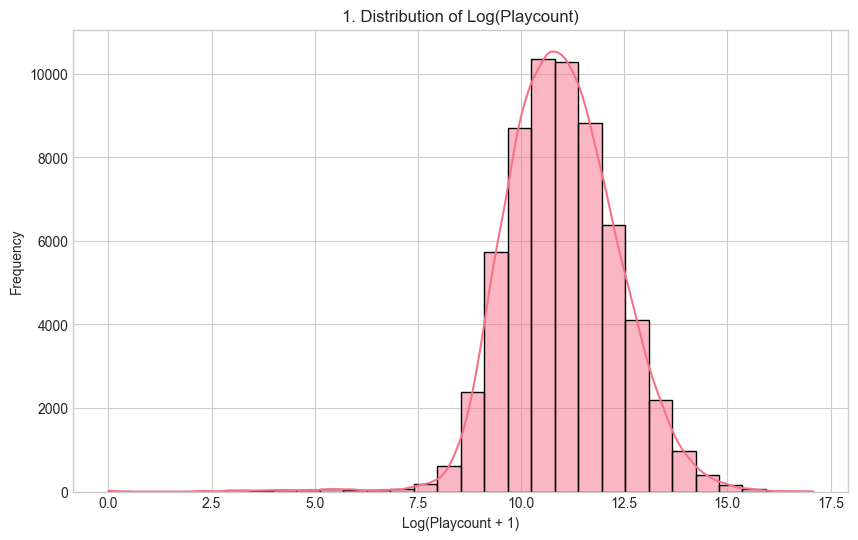

In [25]:
# 1. Distribution of Log(Playcount)
plt.figure(figsize=(10, 6))
sb.histplot(np.log1p(df['playcount']), bins=30, kde=True)
plt.title('1. Distribution of Log(Playcount)')
plt.xlabel('Log(Playcount + 1)')
plt.ylabel('Frequency')

## BPM Distribution: Popular vs Normal Maps
We segmented the top 10% most played maps and compared their BPM distribution to the rest of the dataset. There is a clear difference between the BPM of the top 10% of songs and the rest. Lower BPM maps, generally in the 75-150 range, are significantly less represented in the top 10% of maps compared to higher BPM maps. There is a clear spike around the 175 BPM range where a large majority of maps of maps in this range are in the top 10% of playcount. This indicates that players prefer songs with a higher bpm and that it directly contributes to the popularity of a map.

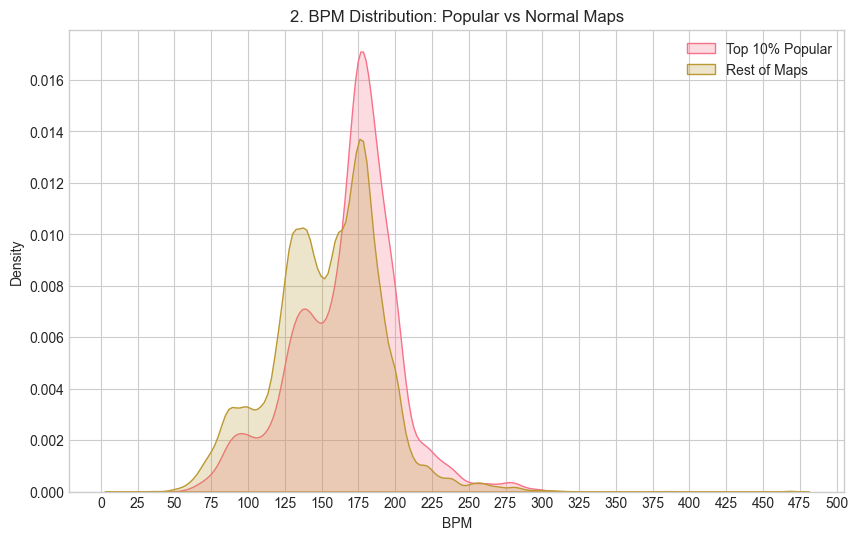

In [26]:
# Calculate Top 10%
top_10 = df[df['playcount'] > df['playcount'].quantile(0.9)]
rest = df[df['playcount'] <= df['playcount'].quantile(0.9)]

plt.figure(figsize=(10, 6))
sb.kdeplot(top_10['bpm'], label='Top 10% Popular', fill=True)
sb.kdeplot(rest['bpm'], label='Rest of Maps', fill=True)
plt.title('2. BPM Distribution: Popular vs Normal Maps')
plt.xlabel('BPM')
plt.ylabel('Density')
plt.gca().xaxis.set_major_locator(MultipleLocator(25))  #set x axsis ticker to a multiple of 25
plt.legend()

## Total Length Distrubition: Popular vs. Normal Maps <br>
Similar to BPM, this looks at song length. Most popular beatmaps often fall into the "TV Size" category (roughly 90 seconds, around the same time as a typical TV anime opening) because they are quick to retry and farm for performance points (PP).

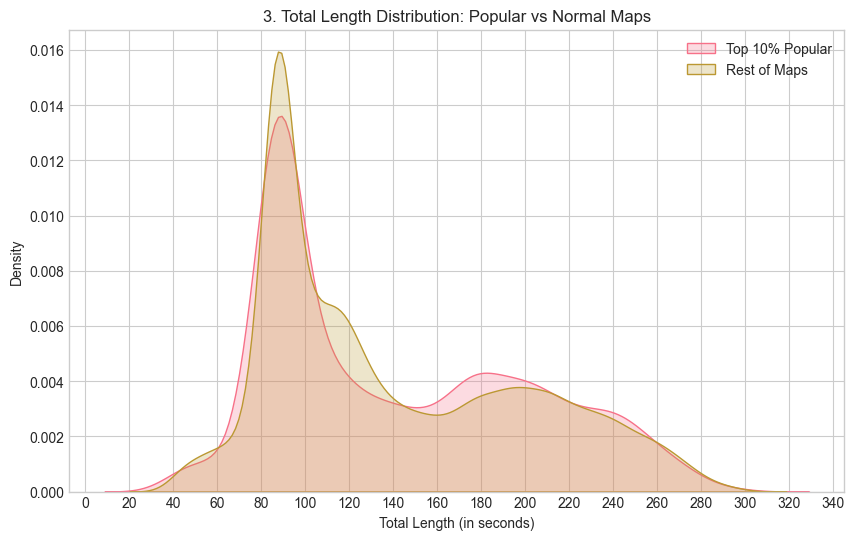

In [27]:
plt.figure(figsize=(10, 6))
sb.kdeplot(top_10['total_length'], label='Top 10% Popular', fill=True)
sb.kdeplot(rest['total_length'], label='Rest of Maps', fill=True)
plt.title('3. Total Length Distribution: Popular vs Normal Maps')
plt.xlabel('Total Length (in seconds)')
plt.ylabel('Density')
plt.gca().xaxis.set_major_locator(MultipleLocator(20))
plt.legend()

## Difficulty Rating vs. Playcount <br>
This scatterplot allows us to see the "sweet spot" for difficulty. Often, maps that are too easy or too overwhelmingly difficult have lower playcounts, while those in the mid-to-high difficulty range (e.g., 4 to 6 stars) attract the largest player base because they are challenging but accessible.

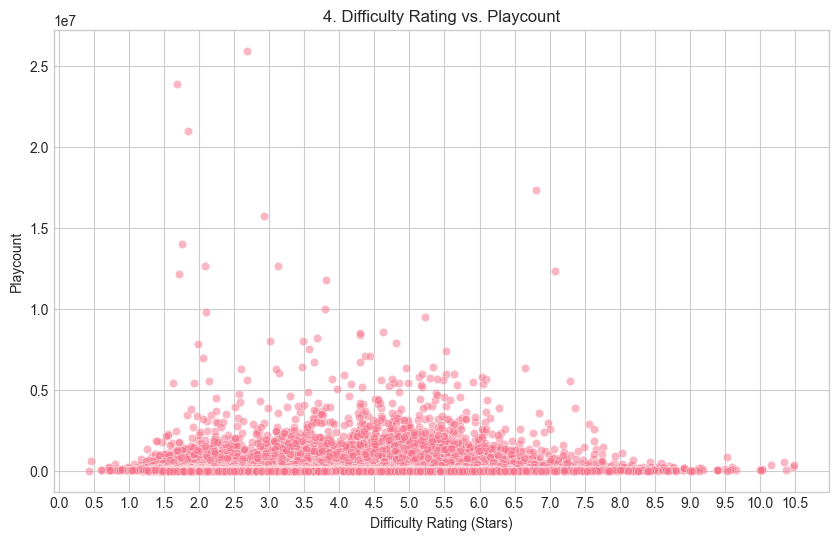

In [28]:
plt.figure(figsize=(10, 6))
sb.scatterplot(x='difficultyrating', y='playcount', alpha=0.5, data=df)
plt.title('4. Difficulty Rating vs. Playcount')
plt.xlabel('Difficulty Rating (Stars)')
plt.ylabel('Playcount')
plt.gca().xaxis.set_major_locator(MultipleLocator(0.5))


## Replayability vs. Appreciation (High Replay vs High Appreciation) <br>
By plotting the Replay Ratio (playcount divided by passcount) against the favourite_count, we can clearly identify distinct groups. The color represents the difficulty rating. Maps in the bottom-right have players retrying them endlessly (high replayability, often very difficult maps), while maps in the top-left are heavily favorited but not necessarily spammed (high appreciation, perhaps visually stunning or musically engaging maps)

Text(0, 0.5, 'Log(Favourite Count) [Appreciation]')

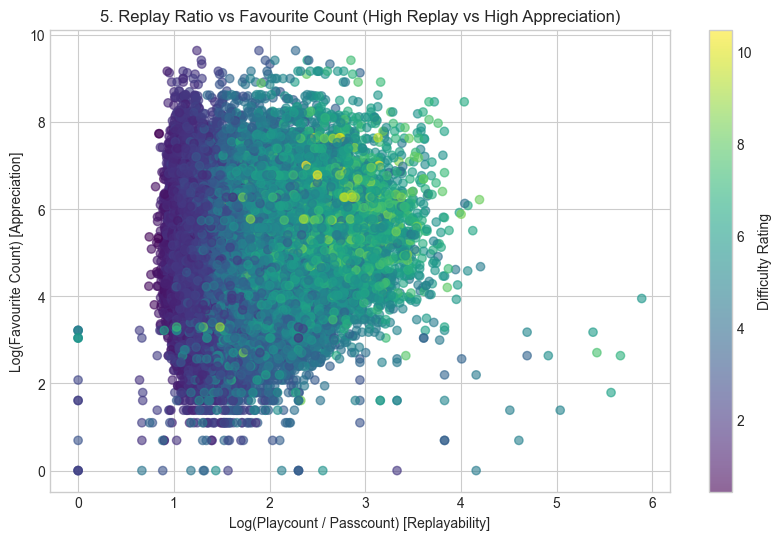

In [29]:
df['replay_ratio'] = df['playcount'] / (df['passcount'] + 1)
plt.figure(figsize=(10, 6))
scatter = plt.scatter(np.log1p(df['replay_ratio']), np.log1p(df['favourite_count']), c=df['difficultyrating'], cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Difficulty Rating')
plt.title('5. Replay Ratio vs Favourite Count (High Replay vs High Appreciation)')
plt.xlabel('Log(Playcount / Passcount) [Replayability]')
plt.ylabel('Log(Favourite Count) [Appreciation]')

## Correlation Heatmap of Key Features <br>
This heatmap reveals how different numerical features interact. For example, max_combo and total_length are highly correlated. In relation to discovery question A, there is a clear correlation between playcount and difficulty rating. This shows that the more difficult a map is, generally it recieves more plays than easier maps. Another example is the interesting correlation between a songs rating and its max combo, hinting that songs with a higher max combo generally recieve a better rating than maps with a lower max combo.

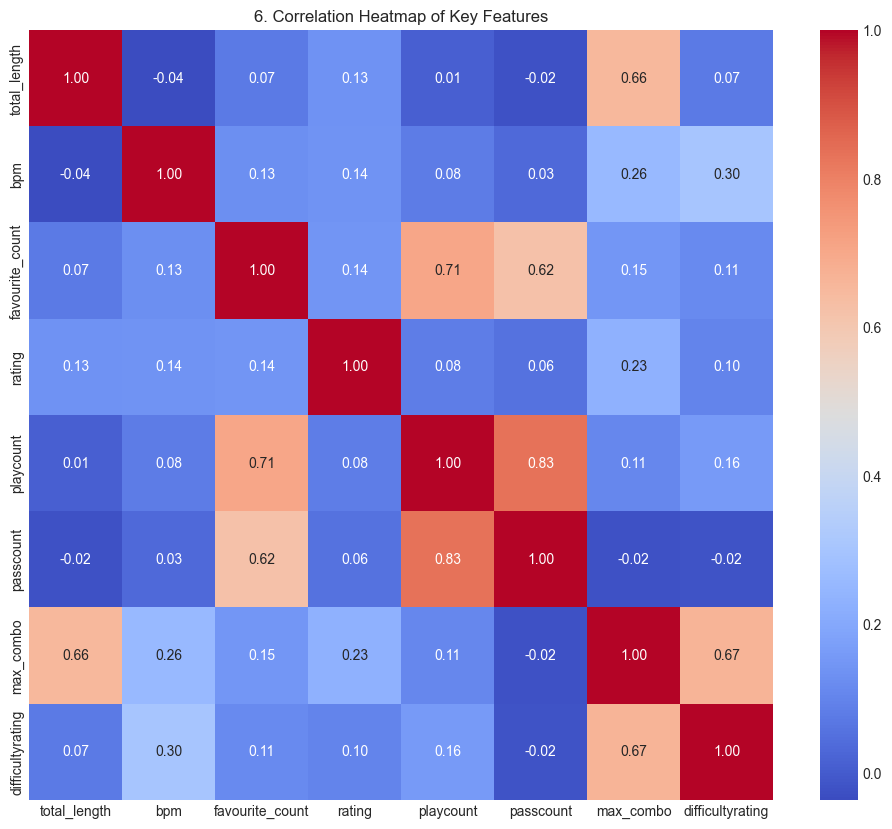

In [30]:
plt.figure(figsize=(12, 10))
cols = ['total_length', 'bpm', 'favourite_count', 'rating', 'playcount', 'passcount', 'max_combo', 'difficultyrating']
sb.heatmap(df[cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('6. Correlation Heatmap of Key Features')
plt.show()